In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Visual settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries successfully loaded.")

Libraries successfully loaded.


In [15]:
# Load Dataset
df = pd.read_excel('Superstore Dataset Source (1).xlsx', sheet_name='Orders')

# Set reference date for recency calculation (day after maximum order date)
ref_date = df['Order Date'].max() + pd.Timedelta(days=1)

# Calculate Recency, Frequency, and Monetary (RFM) per Customer
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (ref_date - x.max()).days,  # Recency
    'Order ID': 'nunique',                             # Frequency
    'Sales': 'sum'                                     # Monetary
}).reset_index()

rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

print("=== RFM DESCRIPTIVE STATISTICS ===")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))
rfm.head()

=== RFM DESCRIPTIVE STATISTICS ===
       Recency  Frequency  Monetary
count   793.00     793.00    793.00
mean    147.80       6.32   2896.85
std     186.21       2.55   2628.67
min       1.00       1.00      4.83
25%      31.00       5.00   1146.05
50%      76.00       6.00   2256.39
75%     184.00       8.00   3785.28
max    1166.00      17.00  25043.05


,Customer_ID,Recency,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


RFM Summary Observation:Recency: Averages ~148 days, ranging from 1 to 1,166 days.Frequency: Customers average 6.3 unique orders (max of 17).Monetary: Mean customer spend is $2,896.85, with high variability ($\sigma = 2628.67$).

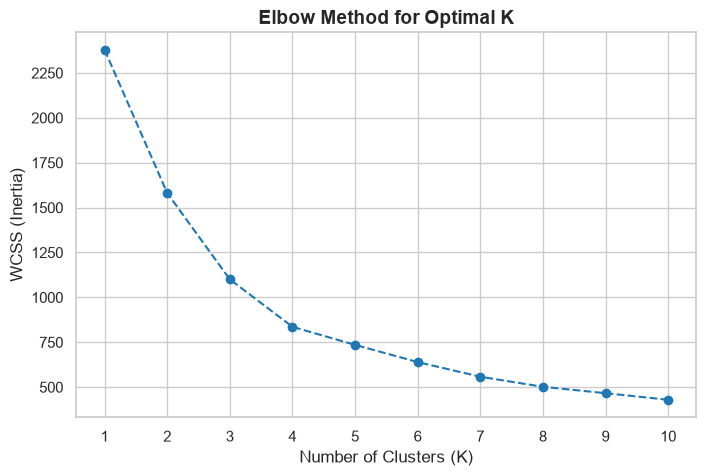

In [16]:
# Standardize features prior to K-Means
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Elbow Method to determine optimal K
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', color='#1f77b4', linestyle='--')
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.show()

Elbow Method Observation:
The total within-cluster sum of squares (WCSS) drops sharply up to K = 3, where the curve forms an "elbow" before leveling off. Hence, $K=3$ is selected as the optimal number of clusters.

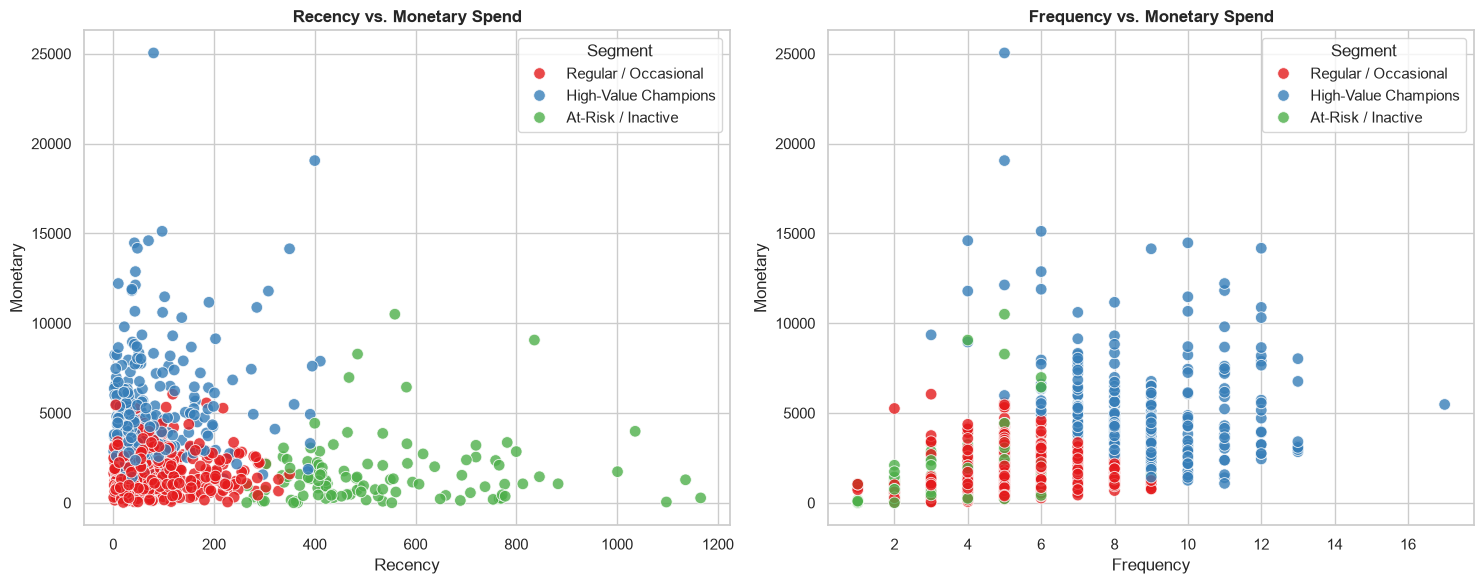

In [17]:
# Apply KMeans with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Map cluster IDs to descriptive names based on profile
cluster_names = {
    0: 'At-Risk / Inactive',
    1: 'High-Value Champions',
    2: 'Regular / Occasional'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_names)

# Visualizing Clusters: Recency vs Monetary & Frequency vs Monetary
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=rfm, x='Recency', y='Monetary', hue='Segment', 
    palette='Set1', ax=axes[0], alpha=0.8, s=70
)
axes[0].set_title('Recency vs. Monetary Spend', fontsize=12, fontweight='bold')

sns.scatterplot(
    data=rfm, x='Frequency', y='Monetary', hue='Segment', 
    palette='Set1', ax=axes[1], alpha=0.8, s=70
)
axes[1].set_title('Frequency vs. Monetary Spend', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

=== CLUSTER PROFILES ===
                      Recency  Frequency  Monetary
Segment                                           
At-Risk / Inactive     531.42       3.77   1636.86
High-Value Champions    80.32       8.84   5140.99
Regular / Occasional    88.65       5.36   1773.81


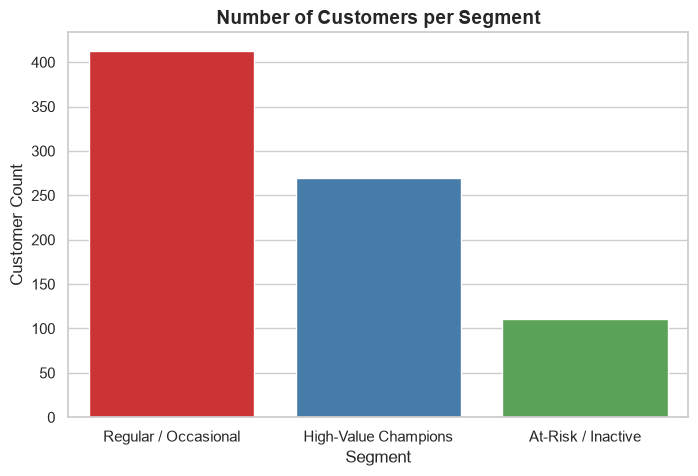

In [18]:
# Mean feature values per cluster
cluster_profile = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("=== CLUSTER PROFILES ===")
print(cluster_profile)

# Bar chart of customer counts per segment
plt.figure(figsize=(8, 5))
sns.countplot(data=rfm, x='Segment', hue='Segment', palette='Set1', legend=False)
plt.title('Number of Customers per Segment', fontsize=14, fontweight='bold')
plt.ylabel('Customer Count')
plt.show()

## Segment Profiles & Targeted Marketing Action Recommendations

**High-Value Champions (Cluster 1):**
* **Profile**: Low Recency (approx. 80 days), High Frequency (8.8 orders), High Spend ($5,141).
* **Action**: Implement VIP loyalty rewards, early product launch access, and personalized account management to retain top spenders.

**Regular / Occasional (Cluster 2):**
* **Profile**: Low Recency (approx. 89 days), Moderate Frequency (5.4 orders), Moderate Spend ($1,774).
* **Action**: Upsell via product bundles and cross-category discounts to increase order frequency and monetary value.

**At-Risk / Inactive (Cluster 0):**
* **Profile**: High Recency (approx. 531 days), Low Frequency (3.8 orders), Low Spend ($1,637).
* **Action**: Execute win-back email campaigns with limited-time discount vouchers to re-engage dormant accounts.